# AI 协作满意度分析：合成数据演示

这是本次新建的公开展示 Notebook，不是历史原代码或真实业务 SEM 的复现。每一项数值来自合成数据。项目叙事与真实结果核对须分开进行。

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
assert (ROOT / "src").exists(), "请从仓库根目录或 notebooks 目录启动。"
sys.path.insert(0, str(ROOT))
from src.generate_demo import generate_demo
from src.audit import field_inventory, clean_sessions, check_gating
from src.sql_demo import run_sql
from src.model import run_models
raw, events = generate_demo(n=2400, seed=42)
print("合成原始记录形状：", raw.shape)


合成原始记录形状： (2412, 26)


## 1. 当前步骤：全字段盘点
为什么：标识、标签、下游结果和口径变更字段不能与行为前因混用。
得到什么：每一列有类型、缺失率、唯一值数及去向说明。

In [2]:
inventory = field_inventory(raw)
display(inventory[["field", "role", "missing_pct", "n_unique", "reason"]])

,field,role,missing_pct,n_unique,reason
0,session_id,metadata,0.000000,2400,仅去重与连接；不是预测特征
1,user_id,metadata,0.000000,970,0 仅表示未登录；不可将所有 0 合为一人
2,anonymous_id,metadata,79.519071,241,仅用于演示分组；全部为合成标识
3,survey_time,metadata,0.000000,2396,限定事件窗口；重复问卷保留最新提交
4,period,group,0.000000,4,仅分组展示；不对应真实业务日期
5,entry_source,group,0.000000,3,用于分层检查；演示主模型不纳入
6,score,target,0.331675,6,1–5 有序结果，不得进入特征白名单
7,age_level,control,9.991708,4,控制项；按 0–3 等距近似仅用于演示
8,is_returning,control,0.000000,2,问卷前已知的二元控制项
9,quick_result_count,behavior,0.000000,8,问卷前事件计数；训练集 P99 缩尾后 log1p


## 2. 当前步骤：样本清洗与门控核验
为什么：按会话处理重复提交；不能把所有匿名 0 当成同一人。问卷后标签只能在明确范围内使用。

In [3]:
clean, audit = clean_sessions(raw)
display(audit)
display(check_gating(clean))

{'raw_rows': 2412,
 'unique_sessions_before_outcome_filter': 2400,
 'duplicate_rows_removed': 12,
 'invalid_outcome_rows_removed': 14,
 'valid_sessions': 2386,
 'anonymous_sessions_retained': 490,
 'session_key_fallbacks': 0,
 'unit': 'session/questionnaire, not unique persons'}

{'positive_tags_at_low_score': 0,
 'negative_tags_at_high_score': 0,
 'mixed_branch_tags': 0,
 'no_tag_selected': 347,
 'warning': 'Rules must be checked against the questionnaire; zero violations do not prove causality or independence.'}

## 3. 当前步骤：SQL 构造事前事件特征
为什么：只聚合同一会话问卷之前的事件，避免引入未来信息。
下一步：把 SQL 汇总与已知的演示事件计数对照。

In [4]:
sql_features = run_sql(raw, events, ROOT / "sql/session_features.sql")
from src.schema import COUNT_FEATURES
expected = clean.set_index("session_id")
actual = sql_features.set_index("session_id").loc[expected.index]
for name in COUNT_FEATURES:
    assert (actual[name].to_numpy() == expected[name].to_numpy()).all()
print("SQL 与 Python 的四类事件计数一致；两条未来事件未计入。")
display(sql_features.head())

SQL 与 Python 的四类事件计数一致；两条未来事件未计入。


,session_id,score,quick_result_count,consult_result_count,followup_shown_count,followup_click_count
0,demo_session_00014,5.0,2,2,5,1
1,demo_session_00015,5.0,1,1,2,0
2,demo_session_00016,5.0,1,0,5,2
3,demo_session_00017,5.0,0,0,1,0
4,demo_session_00018,4.0,3,1,5,2


## 4. 当前步骤：训练集内预处理与模型演示
为什么：参与者不跨训练/留出；P99 与标准化只从训练集学习。
边界：OLS 将评分近似等距，有序 Logit 仍需要模型假设；结果只表示合成样本中的关联。

In [5]:
model_summary, tables = run_models(clean, seed=42)
display(model_summary)
display(tables["coefficients"])
display(tables["ordinal_sensitivity"])

{'provenance': 'synthetic reconstruction; not historical project results',
 'seed': 42,
 'train_sessions': 1803,
 'test_sessions': 583,
 'participant_overlap': 0,
 'baseline': {'train_r2': 0.05527342485877429,
  'test_r2': 0.04968774407004417,
  'test_mae': 0.7796841313980986},
 'leakage_demonstration': {'train_r2': 0.4727635600217346,
  'test_r2': 0.43381378461181286,
  'test_mae': 0.6051167803248066,
  'valid_for_prediction': False},
 'ordinal_sensitivity': {'converged': True,
  'test_mae_expected_score': 0.7825086399609952,
  'note': 'Model-based exploratory fit; not an ordered SEM or a reproduction of the original model.'},
 'scaled_design_condition_number': 2.428103436560162,
 'preprocessing': {'fit_on': 'training only',
  'p99_caps': {'quick_result_count': 5.0,
   'consult_result_count': 3.0,
   'followup_shown_count': 6.0,
   'followup_click_count': 3.0}},
 'interpretation': 'OLS approximates the ordinal score as equally spaced; coefficients are conditional associations, not cau

,feature,standardized_beta,ci_low,ci_high,p_value_clustered
0,quick_result_count,0.173376,0.121298,0.225454,1.069289e-10
1,consult_result_count,0.039230,-0.007689,0.086149,1.011491e-01
2,followup_shown_count,0.110044,0.045808,0.174280,8.058038e-04
3,followup_click_count,-0.075183,-0.133694,-0.016672,1.184667e-02
4,is_returning,0.035947,-0.010031,0.081924,1.252773e-01
5,age_level,0.079237,0.031556,0.126917,1.149794e-03
6,age_unknown,0.041117,-0.006062,0.088296,8.753351e-02


,feature,ordinal_log_odds_per_sd,same_direction_as_ols
0,quick_result_count,0.350700,True
1,consult_result_count,0.084816,True
2,followup_shown_count,0.211761,True
3,followup_click_count,-0.156909,True
4,is_returning,0.067016,True
5,age_level,0.141969,True
6,age_unknown,0.072623,True


## 5. 当前步骤：理解泄漏反例
两个模型使用同一留出集。含评分后标签的方案即使分数更高，也不能当成有效的事前预测。留出集表现不会自动修复特征时序问题。

In [6]:
display(pd.DataFrame({"baseline": model_summary["baseline"], "invalid_leakage_demo": model_summary["leakage_demonstration"]}))

,baseline,invalid_leakage_demo
train_r2,0.055273,0.472764
test_r2,0.049688,0.433814
test_mae,0.779684,0.605117
valid_for_prediction,NaN,False


## 6. 当前步骤：生成图表
每张图都由本次合成结果重新绘制，并标明 SYNTHETIC / DEMO。

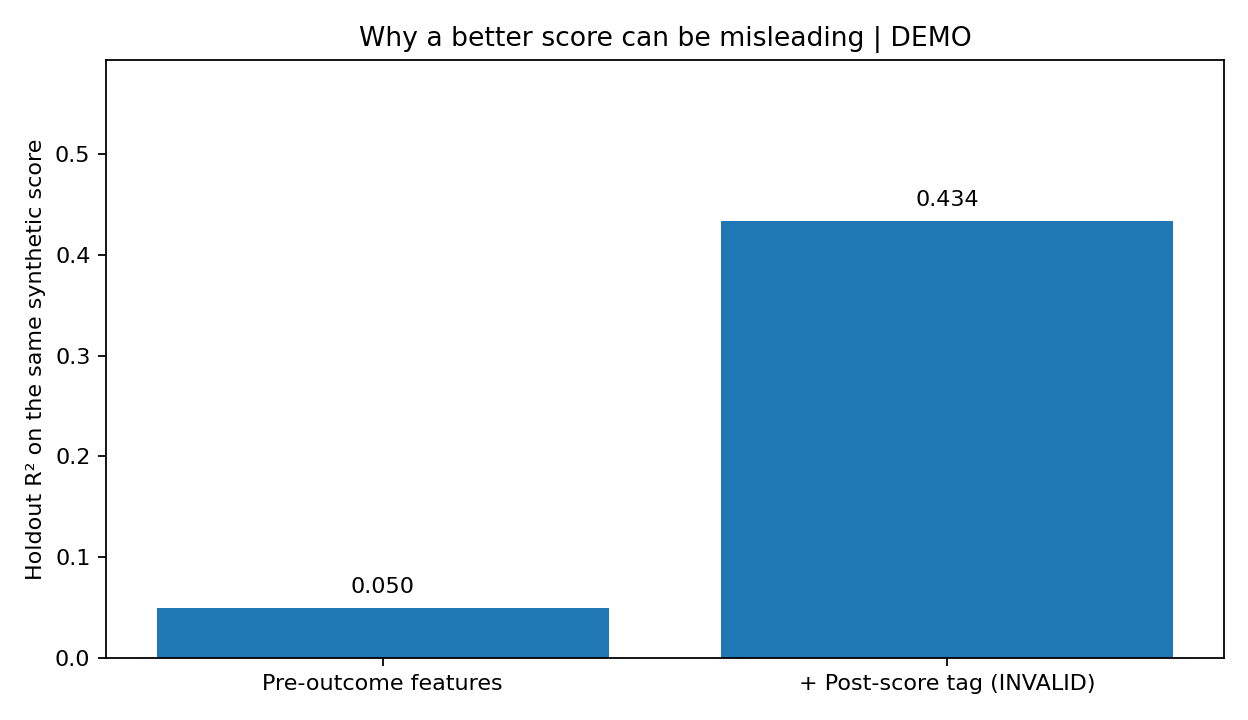

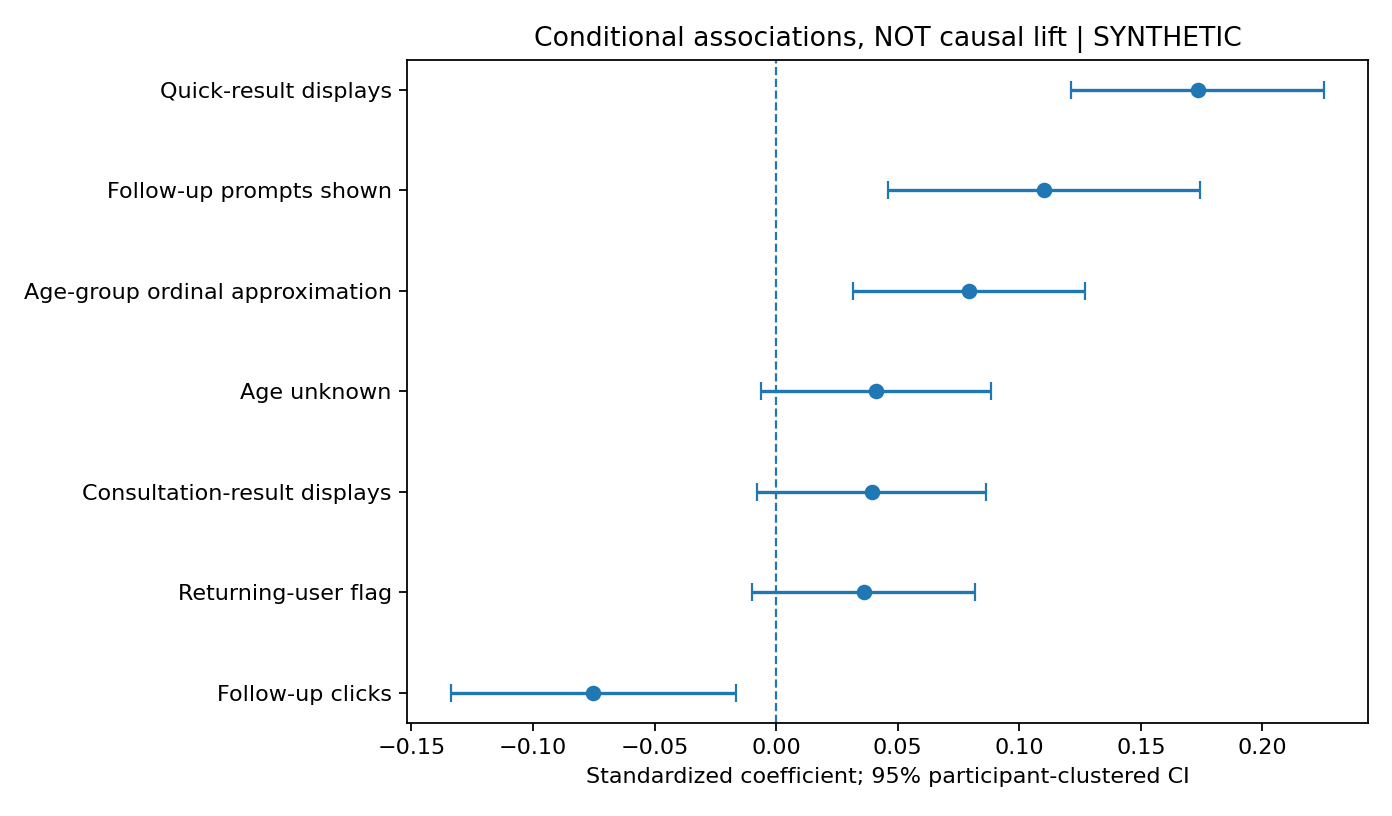

In [7]:
from src.plots import make_plots
make_plots(clean, model_summary, tables["coefficients"], ROOT / "assets")
display(Image(filename=str(ROOT / "assets/leakage_demo.png")))
display(Image(filename=str(ROOT / "assets/coefficient_associations.png")))

## 7. 结论与下一步

本演示展示全字段审计、问卷门控风险、事前事件聚合、条件系数解释与可追溯输出。它不验证任何真实业务的因果效果，也不重现原 SEM。

原项目复现需要有权限的数据快照、完整模型语法、估计器设置、字段字典和正式报告。公开作品请保留上述边界声明。